In [1]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
fdtdApi = lumapi.FDTD(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Geometria

In [2]:
microns = 1e-6
wco1 = 1.5 *microns
wco2 = 0.8 *microns
H = 0.4 *microns
f = 0.5
h_et = f * H
waveguide_width = 5 *microns
waveguide_len = 20 * microns # 1 um fora do solver, 0.5 um entre o solver e a porta e 8.5 um entre a porta e o taper 
Ltp = 22.4 *microns

In [3]:
# Taper

fdtdApi.addrect()
fdtdApi.set("name", "lower_rect_taper")
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", 0)
fdtdApi.set("x span", Ltp)
fdtdApi.set("y span", waveguide_width)
fdtdApi.set("z span", H - h_et)
fdtdApi.set("material", "Si (Silicon) - Palik")

fdtdApi.addobject("linear_taper")
fdtdApi.set("name", "taper")
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", H/2)
fdtdApi.set("thickness", h_et)
fdtdApi.set("angle_side", 90)
fdtdApi.set("width_l", wco1)
fdtdApi.set("width_r", wco2)
fdtdApi.set("len", Ltp)
fdtdApi.set("material", "Si (Silicon) - Palik")


In [4]:
# Guia RIB maior

fdtdApi.addrect()
fdtdApi.set("name", "lower_rect_wco1")
fdtdApi.set("x", -(Ltp + waveguide_len)/2)
fdtdApi.set("y", 0)
fdtdApi.set("z", 0)
fdtdApi.set("x span", waveguide_len)
fdtdApi.set("y span", waveguide_width)
fdtdApi.set("z span", H - h_et)
fdtdApi.set("material", "Si (Silicon) - Palik")

fdtdApi.addrect()
fdtdApi.set("name", "upper_rect_wco1")
fdtdApi.set("x", -(Ltp + waveguide_len)/2)
fdtdApi.set("y", 0)
fdtdApi.set("z", H/2)
fdtdApi.set("x span", waveguide_len)
fdtdApi.set("y span", wco1)
fdtdApi.set("z span", h_et)
fdtdApi.set("material", "Si (Silicon) - Palik")


In [5]:
# Guia RIB menor

fdtdApi.addrect()
fdtdApi.set("name", "lower_rect_wco1")
fdtdApi.set("x", (Ltp + waveguide_len)/2)
fdtdApi.set("y", 0)
fdtdApi.set("z", 0)
fdtdApi.set("x span", waveguide_len)
fdtdApi.set("y span", waveguide_width)
fdtdApi.set("z span", H - h_et)
fdtdApi.set("material", "Si (Silicon) - Palik")

fdtdApi.addrect()
fdtdApi.set("name", "upper_rect_wco1")
fdtdApi.set("x", (Ltp + waveguide_len)/2)
fdtdApi.set("y", 0)
fdtdApi.set("z", H/2)
fdtdApi.set("x span", waveguide_len)
fdtdApi.set("y span", wco2)
fdtdApi.set("z span", h_et)
fdtdApi.set("material", "Si (Silicon) - Palik")


In [6]:
solver_xspan = 2*waveguide_len + Ltp - 2*microns
solver_yspan = waveguide_width + 2*microns
solver_zspan = 1*microns
freqpoints = 11

In [7]:
# Solver

fdtdApi.addfdtd()
fdtdApi.set("background material", "SiO2 (Glass) - Palik")

fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", h_et/2)
fdtdApi.set("x span", solver_xspan)
fdtdApi.set("y span", solver_yspan)
fdtdApi.set("z span", solver_zspan)

fdtdApi.set('global source wavelength start', 1.5 *microns)
fdtdApi.set('global source wavelength stop', 1.6 *microns)
fdtdApi.set('global monitor frequency points', freqpoints)
fdtdApi.set('Mesh accuracy', 4)
fdtdApi.set('simulation time', 3.5*(10**(-12)))

In [8]:
porta_yspan = waveguide_width + 1*microns

In [9]:
# Portas

fdtdApi.addport()
fdtdApi.set('name', 'porta_wco1')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -(Ltp/2 + waveguide_len - 1.5*microns))
fdtdApi.set('y', 0)
fdtdApi.set('z', h_et/2)
fdtdApi.set('y span', porta_yspan)
fdtdApi.set('z span', solver_zspan)
fdtdApi.set("mode selection", "fundamental TM mode")

fdtdApi.addport()
fdtdApi.set('name', 'porta_wco2')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', Ltp/2 + waveguide_len - 1.5*microns)
fdtdApi.set('y', 0)
fdtdApi.set('z', h_et/2)
fdtdApi.set('y span', porta_yspan)
fdtdApi.set('z span', solver_zspan)

In [10]:
# Monitores

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", h_et/2)
fdtdApi.set("x span", solver_xspan)
fdtdApi.set("y span", solver_yspan)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', freqpoints)
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", h_et/2)
fdtdApi.set("x span", solver_xspan)
fdtdApi.set("y span", solver_yspan)

In [ ]:
fdtdApi.addpower()
fdtdApi.set('name', 'power')
fdtdApi.set("x", fdtdApi.getnamed("FDTD::ports::porta_wco2", "x") - 0.1*microns)
fdtdApi.set("y", 0)
fdtdApi.set("z", h_et/2)
fdtdApi.set("monitor type", 5)
fdtdApi.set("z span", solver_zspan)
fdtdApi.set("y span", porta_yspan)


fdtdApi.addmodeexpansion()
fdtdApi.set('name', 'mode_expansion')
fdtdApi.set("x", fdtdApi.getnamed("FDTD::ports::porta_wco2", "x") - 0.2*microns)
fdtdApi.set("y", 0)
fdtdApi.set("z", h_et/2)
fdtdApi.set("monitor type", 5)
fdtdApi.set("z span", solver_zspan)
fdtdApi.set("y span", porta_yspan)

In [ ]:
fdtdApi.setnamed("mode_expasion")

In [ ]:
fdtdApi.save('Mode_conversor_FDTD')
fdtdApi.run(3)

In [ ]:
res = fdtdApi.getresult("monitor", "expansion for monitor")

print(res.keys())

dict_keys(['lambda', 'f', 'n', 'T_total', 'T_forward', 'T_backward', 'T_net', 'a', 'b', 'N', 'P', 'Lumerical_dataset'])


In [24]:
T_net = np.array(res["T_net"])
print(len(T_net))

11


In [ ]:
print()

Perfil de campo

In [20]:
fdtdApi.getdata()

'index\nprofile_xy\nmonitor_1\n'

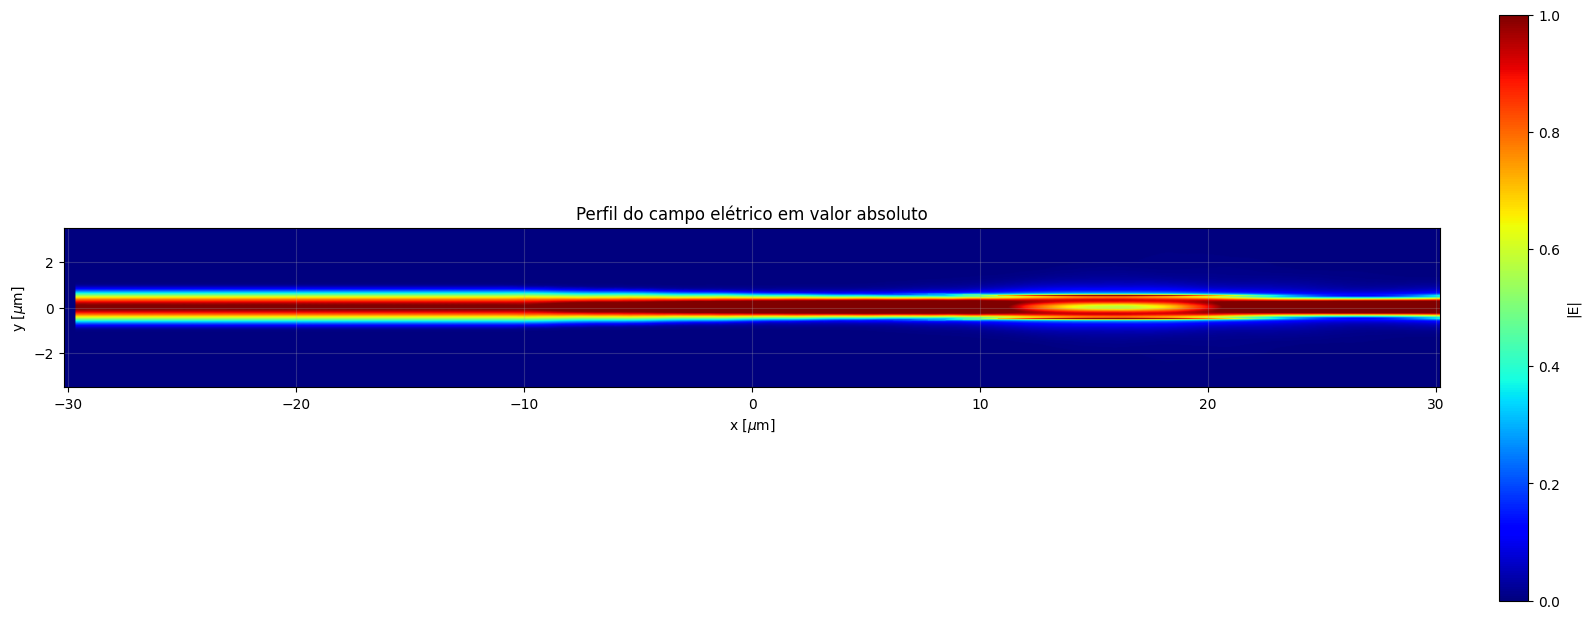

In [ ]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))

indxLambda = 6
x_efield = fdtdApi.getdata("profile_xy", "x")
y_efield = fdtdApi.getdata("profile_xy", "y")
lmbd = nu2lambda(fdtdApi.getdata("profile_xy", "f"))

xmin = np.min(x_efield) /microns
xmax = np.max(x_efield) /microns
ymin = np.min(y_efield) /microns
ymax = np.max(y_efield) /microns

# Escala linear

fig1 = plt.figure(figsize=(16,16))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField[:,:,indxLambda]), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=1)

colorbar = plt.colorbar(im1, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m]')
ax1.set_title("Perfil do campo elétrico em valor absoluto")

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()